In [1]:
# Importazione delle librerie utili per il progetto
import pandas as pandas
import numpy as numpy
import statistics as st
import matplotlib.pyplot as plt

In [2]:
dfhotel_reviews = pandas.read_csv('C:/Users/zagon/OneDrive/Desktop/DFHotel_Reviews_Expanded.csv', sep=';')
print(dfhotel_reviews)

        id_hotel  id_stats  id_review  Additional_Number_of_Scoring  \
0              1         1          0                           194   
1              1         1          1                           194   
2              1         1          2                           194   
3              1         1          3                           194   
4              1         1          4                           194   
...          ...       ...        ...                           ...   
515207      1494      1494     515207                           168   
515208      1494      1494     515208                           168   
515209      1494      1494     515209                           168   
515210      1494      1494     515210                           168   
515211      1494      1494     515211                           168   

       Review_Date  Average_Score  \
0       03/08/2017            7.7   
1       03/08/2017            7.7   
2       31/07/2017            7.7   

In [3]:
dfhotel_reviews.describe(include='all')

,id_hotel,id_stats,id_review,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Address,Hotel_Name,Reviewer_Nationality,Negative_Review,...,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng,Review_Month,Review_Year,Review_Extraction
count,515212.000000,515212.000000,515212.000000,515212.000000,515212,515212.000000,515212,515212,515212,515212,...,515212.000000,515212.000000,515212.000000,515212,515212.000000,515212,515212,515212.000000,515212.000000,515212
unique,NaN,NaN,NaN,NaN,731,NaN,1493,1492,227,330011,...,NaN,NaN,NaN,55242,NaN,1473,1473,NaN,NaN,1
top,NaN,NaN,NaN,NaN,02/08/2017,NaN,163 Marsh Wall Docklands Tower Hamlets London ...,Britannia International Hotel Canary Wharf,United Kingdom,No Negative,...,NaN,NaN,NaN,"[' Leisure trip ', ' Couple ', ' Double Room '...",NaN,515.019.097,-0.0232208,NaN,NaN,03/08/2017
freq,NaN,NaN,NaN,NaN,2584,NaN,4789,4789,245110,127757,...,NaN,NaN,NaN,5101,NaN,4789,4789,NaN,NaN,515212
mean,746.206837,746.206837,257605.500000,498.416021,NaN,8.397767,NaN,NaN,NaN,NaN,...,17.778256,7.164895,8.395532,NaN,354.400474,NaN,NaN,6.486017,2016.120927,NaN
std,432.640188,432.640188,148729.037782,500.668595,NaN,0.547952,NaN,NaN,NaN,NaN,...,21.804541,11.039354,1.637467,NaN,208.908943,NaN,NaN,3.351919,0.687510,NaN
min,1.000000,1.000000,0.000000,1.000000,NaN,5.200000,NaN,NaN,NaN,NaN,...,0.000000,1.000000,2.500000,NaN,0.000000,NaN,NaN,1.000000,2015.000000,NaN
25%,364.000000,364.000000,128802.750000,169.000000,NaN,8.100000,NaN,NaN,NaN,NaN,...,5.000000,1.000000,7.500000,NaN,175.000000,NaN,NaN,4.000000,2016.000000,NaN
50%,758.000000,758.000000,257605.500000,342.000000,NaN,8.400000,NaN,NaN,NaN,NaN,...,11.000000,3.000000,8.800000,NaN,353.000000,NaN,NaN,7.000000,2016.000000,NaN
75%,1116.000000,1116.000000,386408.250000,660.000000,NaN,8.800000,NaN,NaN,NaN,NaN,...,22.000000,8.000000,9.600000,NaN,527.000000,NaN,NaN,9.000000,2017.000000,NaN


In [4]:
# 4.4 Analisi con Pandas 
# Riprodurre analisi SQL principali (group by mensile, ranking nazionalità, distribuzione città)

In [5]:
# Group by mensile

dfhotel_reviews.groupby(['Review_Year', 'Review_Month'])['id_review'].count().reset_index(name='num_reviews').sort_values(['Review_Year', 'Review_Month'])

# risultato identico a SQL

,Review_Year,Review_Month,num_reviews
0,2015,8,19287
1,2015,9,19689
2,2015,10,19449
3,2015,11,18039
4,2015,12,17914
5,2016,1,19496
6,2016,2,18836
7,2016,3,20722
8,2016,4,21471
9,2016,5,23055


In [6]:
# ranking nazionalità

df_nationality = dfhotel_reviews.groupby('Reviewer_Nationality').agg(
num_reviews=('id_review', 'count'),
avg_score=('Reviewer_Score', 'mean')).reset_index()
df_nationality['perc_reviews'] = (df_nationality['num_reviews'] / df_nationality['num_reviews'].sum()) * 100
df_nationality = df_nationality.sort_values('num_reviews', ascending=False)
print(df_nationality.head(10))

# risultato identico a SQL

           Reviewer_Nationality  num_reviews  avg_score  perc_reviews
214             United Kingdom        245110   8.486543     47.574591
216   United States of America         35349   8.786927      6.861059
14                   Australia         21648   8.592507      4.201765
98                     Ireland         14814   8.463953      2.875321
213       United Arab Emirates         10229   7.879695      1.985396
176               Saudi Arabia          8940   7.884139      1.735208
144                Netherlands          8757   8.126573      1.699689
197                Switzerland          8669   8.161979      1.682608
78                     Germany          7929   8.134380      1.538978
38                      Canada          7883   8.548230      1.530050


In [7]:
# Distribuzione città

dfhotel_reviews['city'] = dfhotel_reviews['Hotel_Address'].str.split().str[-2:].str.join(' ')
dfhotel_reviews['city'] =dfhotel_reviews['city'].replace("United Kingdom", "London UK")
df_city = dfhotel_reviews.groupby('city').agg(
num_reviews=('id_review', 'count')
).reset_index()
df_city = df_city.sort_values('num_reviews', ascending=False)
print(df_city)

# risultato identico a SQL

                    city  num_reviews
2              London UK       262298
1        Barcelona Spain        60149
4           Paris France        59413
0  Amsterdam Netherlands        57211
5         Vienna Austria        38937
3            Milan Italy        37204


In [8]:
# robe da fare ancora

In [9]:
# Visualizzazioni con Matplotlib 

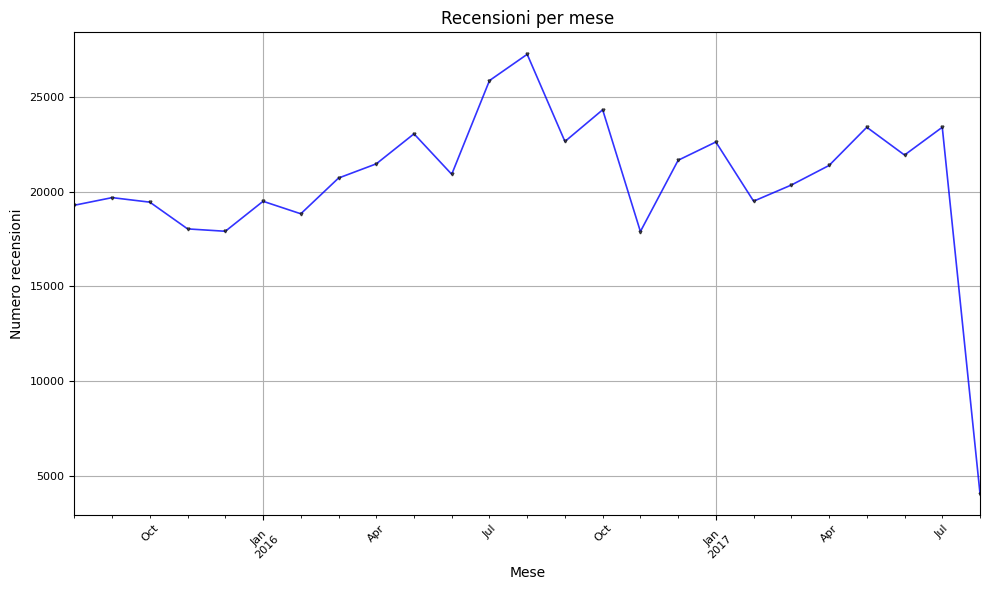

In [10]:
# Line plot recensioni/mese e recensioni/anno

dfhotel_reviews['Review_Date'] = pandas.to_datetime(dfhotel_reviews['Review_Date'],dayfirst=True,errors='coerce')
reviews_month = dfhotel_reviews.groupby(dfhotel_reviews['Review_Date'].dt.to_period('M')).size()
reviews_month.index = reviews_month.index.to_timestamp()

grafico1 = reviews_month.plot(
    kind='line',
    x='reviews_month',
    y='reviews_month.values',

    figsize=(10,6),
    title='Recensioni per mese',
    grid='True',

    color='blue', 
    linewidth=1.2, 
    linestyle='solid', 
    marker='v', #SIMBOLO AI PUNTI DATI 'o' 's' '^' 'v' 'D' '*' '+' 'x'
    markersize=2, #DIMENSIONE DEL MARKER
    markeredgecolor='black', #COLORE BORDO MARKER
    markerfacecolor='white', #COLORE MARKER
    markeredgewidth=1, #SPESSORE BORDO MARKER
    alpha=0.8,

    rot=45, #ROTAZIONE ETICHETTE ASSI IN GRADI
    fontsize=8, #DIMENSIONE DEL FONT ETICHETTE ASSI
    xlabel='Mese', #ETICHETTA DELL'ASSE X
    ylabel='Numero recensioni' #ETICHETTA DELL'ASSE Y 
)

plt.tight_layout()
plt.show()

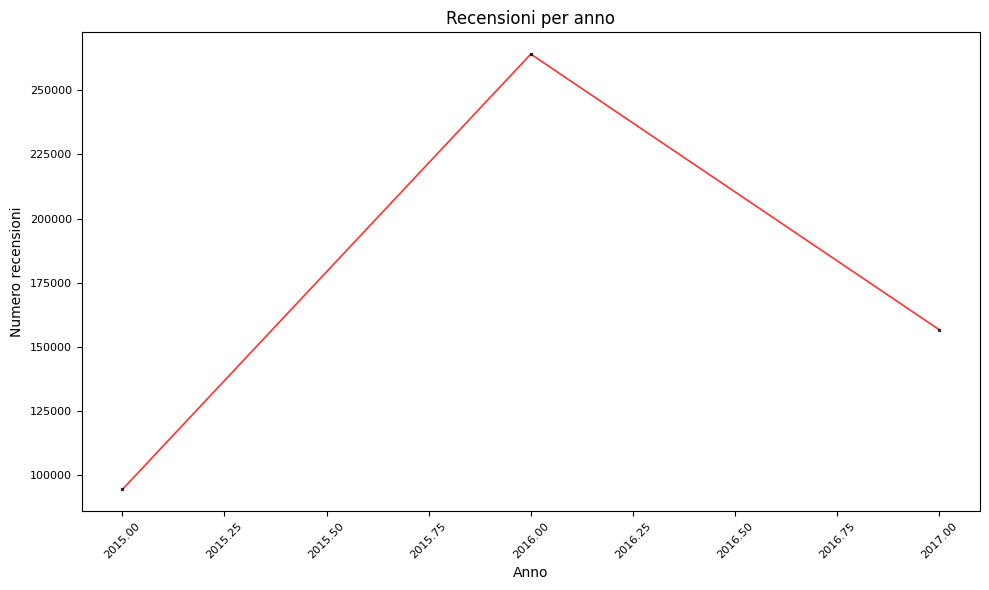

In [12]:
reviews_year = dfhotel_reviews.groupby(dfhotel_reviews['Review_Date'].dt.year).size()

grafico1_2 = reviews_year.plot(
    kind='line',
    x='reviews_year',
    y='reviews_year.values',

    figsize=(10,6),
    title='Recensioni per anno',

    color='red', 
    linewidth=1.2, 
    linestyle='solid', 
    marker='x', #SIMBOLO AI PUNTI DATI 'o' 's' '^' 'v' 'D' '*' '+' 'x'
    markersize=2, #DIMENSIONE DEL MARKER
    markeredgecolor='black', #COLORE BORDO MARKER
    markerfacecolor='white', #COLORE MARKER
    markeredgewidth=1, #SPESSORE BORDO MARKER
    alpha=0.8,

    rot=45, #ROTAZIONE ETICHETTE ASSI IN GRADI
    fontsize=8, #DIMENSIONE DEL FONT ETICHETTE ASSI
    xlabel='Anno', #ETICHETTA DELL'ASSE X
    ylabel='Numero recensioni' #ETICHETTA DELL'ASSE Y 
)

plt.tight_layout()
plt.show()

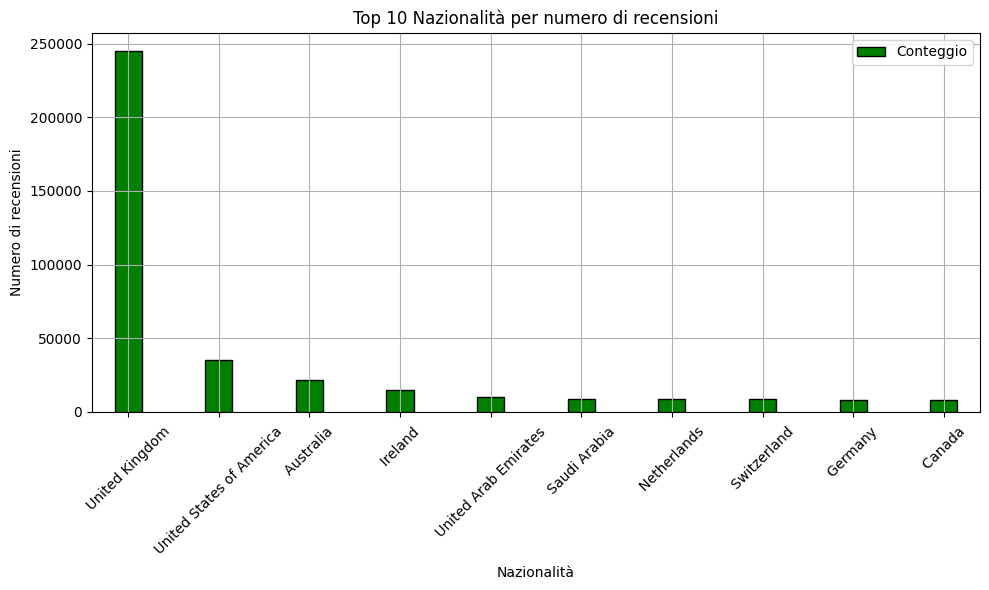

In [ ]:
#  Bar chart top 10 nazionalità per recensioni

dftop10_nationalities = (dfhotel_reviews['Reviewer_Nationality'].value_counts().head(10))

plt.figure(figsize=(10,5))
grafico2 = dftop10_nationalities.plot(
    kind='bar',
    x='dftop10_nationalities',
    
    figsize=(10,6),
    title='Top 10 Nazionalità per numero di recensioni',
    xlabel='Nazionalità',
    ylabel='Numero di recensioni',
    grid='True',
    legend='True',
    label='Conteggio',

    color='green', #COLORE DELLE BARRE
    edgecolor='black', #COLORE DEL BORDO DELLE BARRE
    linewidth=1, #SPESSORE DEL BORDO
    width=0.3, #SPESSO
    
    rot=45,
    fontsize=10
)

plt.tight_layout()
plt.show()

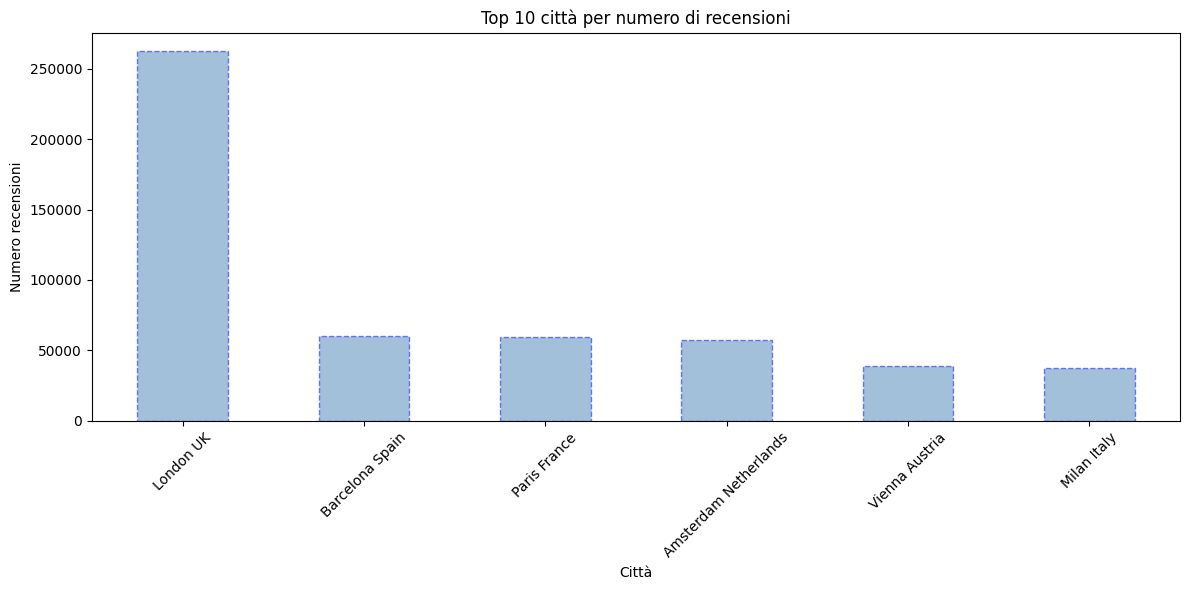

In [14]:
# Bar chart top 10 città per numero recensioni

# Conta recensioni per città
top_cities_per_review = dfhotel_reviews['city'].value_counts().head(10)

grafico3 = top_cities_per_review.plot(
    kind='bar',
    color='steelblue',
    edgecolor='blue',
    linestyle='--', 
    alpha=0.5,
    rot=45,
    figsize=(12,6),

    title='Top 10 città per numero di recensioni',
    xlabel='Città',
    ylabel='Numero recensioni'
)

plt.tight_layout()
plt.show()

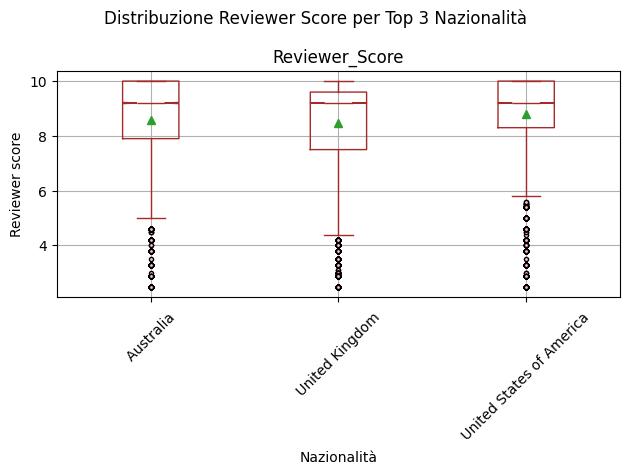

In [15]:
# Box plot distribuzione Reviewer Score per nazionalità top 3

# Top 3 nazionalità per numero di recensioni
dftop3filter = dfhotel_reviews['Reviewer_Nationality'].value_counts().head(3).index

# Filtra il dataset
dftop3_nation = dfhotel_reviews[dfhotel_reviews['Reviewer_Nationality'].isin(dftop3filter)]

# Box plot
grafico4 = dftop3_nation.plot(
    kind='box',
    column='Reviewer_Score',
    by='Reviewer_Nationality',
    grid=True,
    legend=True,
    
    title='Distribuzione Reviewer Score per Top 3 Nazionalità',
    xlabel='Nazionalità',
    ylabel='Reviewer score',

    flierprops=dict(marker='o', markersize=3, markerfacecolor='pink'), 
    showmeans=True, 
    notch=True, 

    color='brown',
    rot=45,
    fontsize=10
    )

plt.tight_layout()
plt.show()

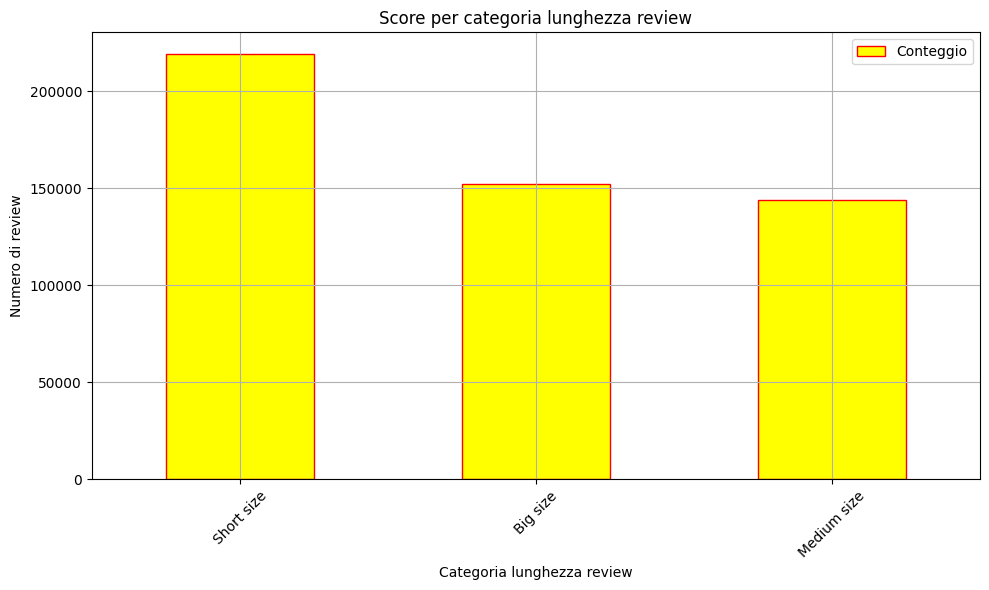

In [ ]:
# Histogram Review Length per categoria score

# lunghezza recensione
dfhotel_reviews['review_length'] = (dfhotel_reviews['Review_Total_Positive_Word_Counts'] + dfhotel_reviews['Review_Total_Negative_Word_Counts'])

# categorie score
dfhotel_reviews['score_category'] = numpy.select([
dfhotel_reviews['review_length'] <= 20,
dfhotel_reviews['review_length'] <= 40],
["Short size","Medium size"],
default="Big size")

plt.figure(figsize=(10,6))

grafico5 = dfhotel_reviews["score_category"].value_counts().plot(
    kind="bar",
    grid=True,
    legend=True,
    label='Conteggio',
    
    title="Score per categoria lunghezza review",
    xlabel='Categoria lunghezza review',
    ylabel='Numero di review',

    edgecolor='red',
    color='yellow',
    rot=45,
    fontsize=10)

plt.tight_layout()
plt.show()




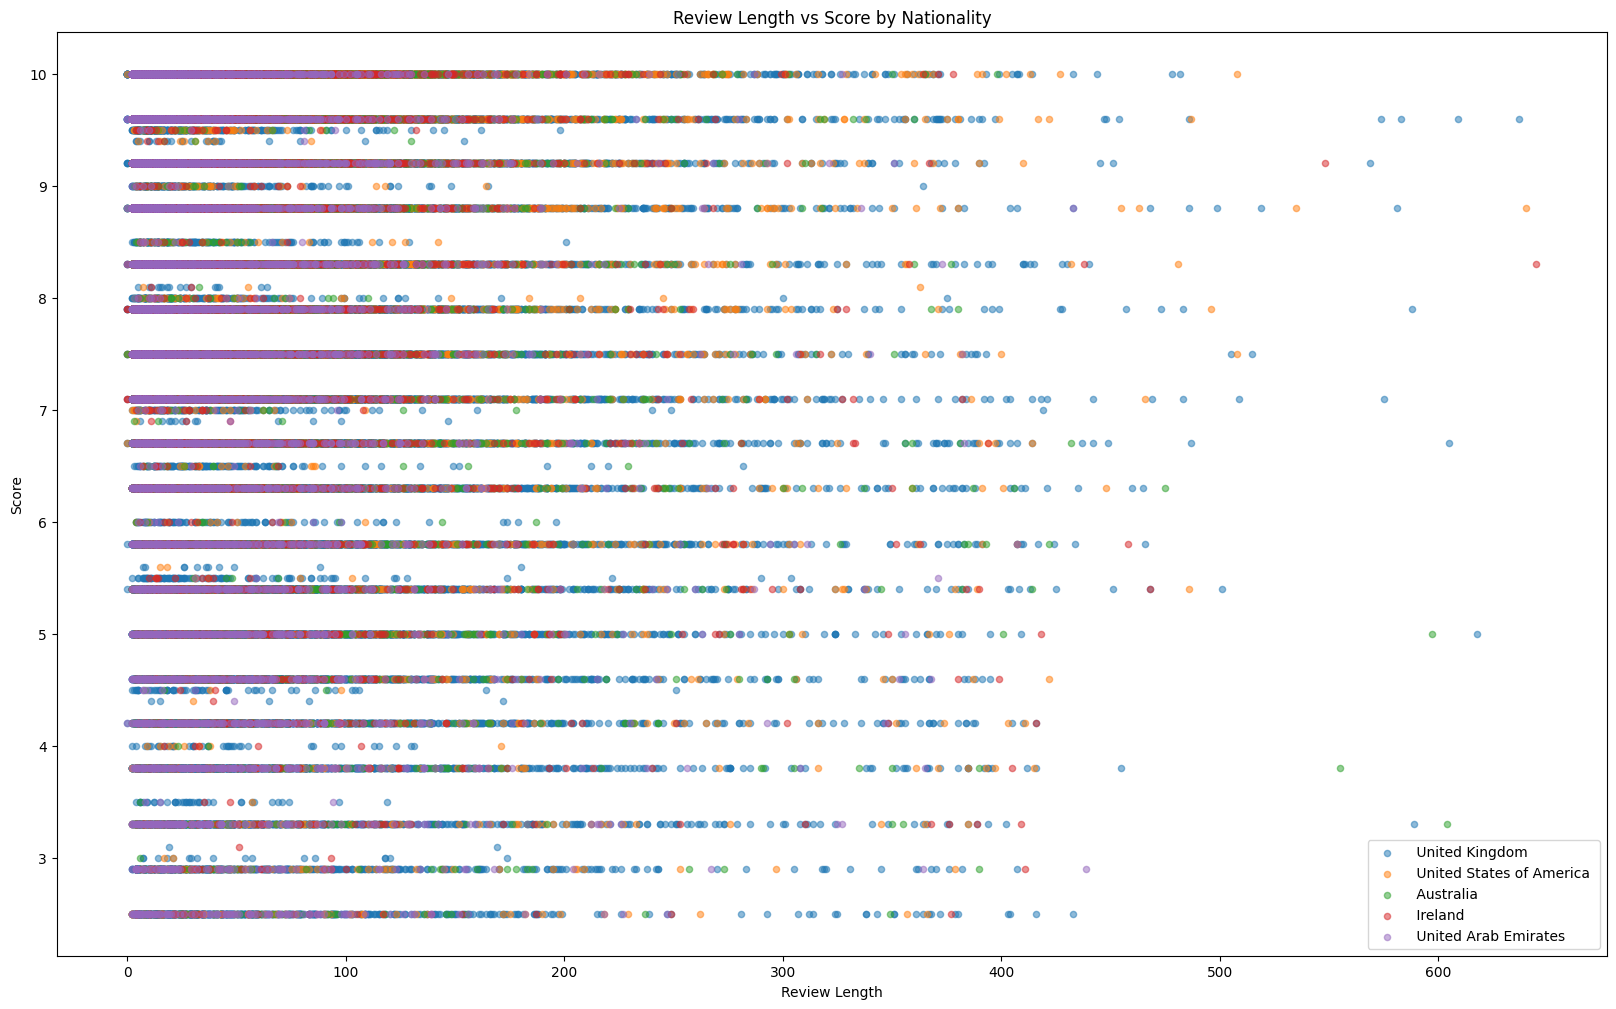

In [ ]:
#  Scatter plot Review Length vs Reviewer Score (colore per nazionalità)

# grafico6

plt.figure(figsize=(20,12))

nation = dfhotel_reviews['Reviewer_Nationality'].value_counts().head(5).index
for n in nation:
    subset = dfhotel_reviews[dfhotel_reviews['Reviewer_Nationality'] == n]
    
    plt.scatter(
        subset['review_length'],
        subset['Reviewer_Score'],
        alpha=0.5,
        label=n,
        s=20
    )

plt.title('Review Length vs Score by Nationality')
plt.xlabel('Review Length')
plt.ylabel('Score')
plt.legend()
plt.show()

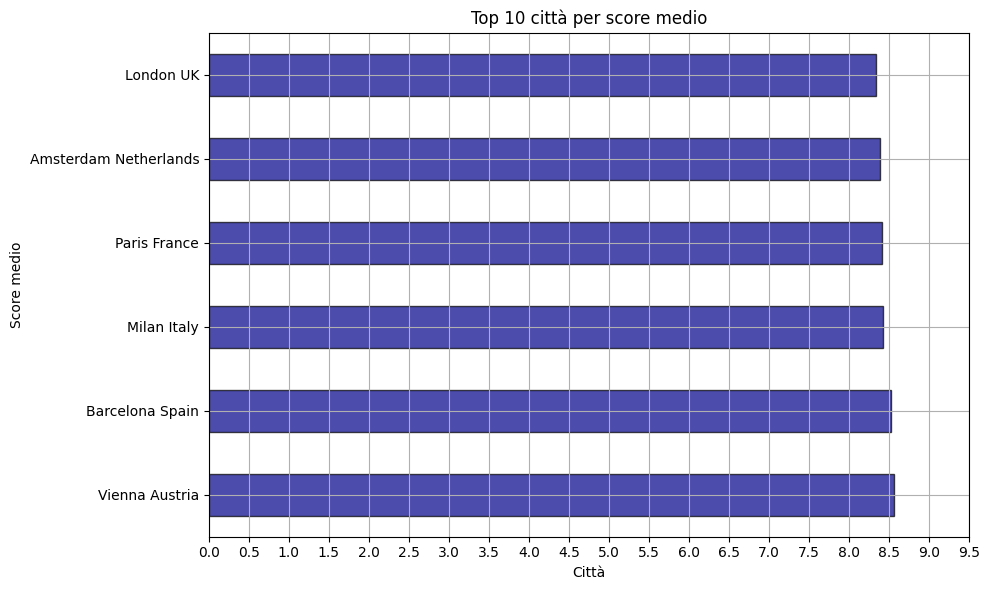

In [17]:
#  Bar chart score medio per top 10 città

top_cities_per_score = (dfhotel_reviews.groupby("city")["Average_Score"].mean().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,6))

grafico7 = top_cities_per_score.plot(
    kind="barh",
    color="darkblue",
    grid='True',
    edgecolor='black',
    alpha=0.7,
    
    title='Top 10 città per score medio',
    xlabel='Città',
    ylabel='Score medio')

plt.xticks(numpy.arange(0, 10, 0.5))

plt.tight_layout()
plt.show()

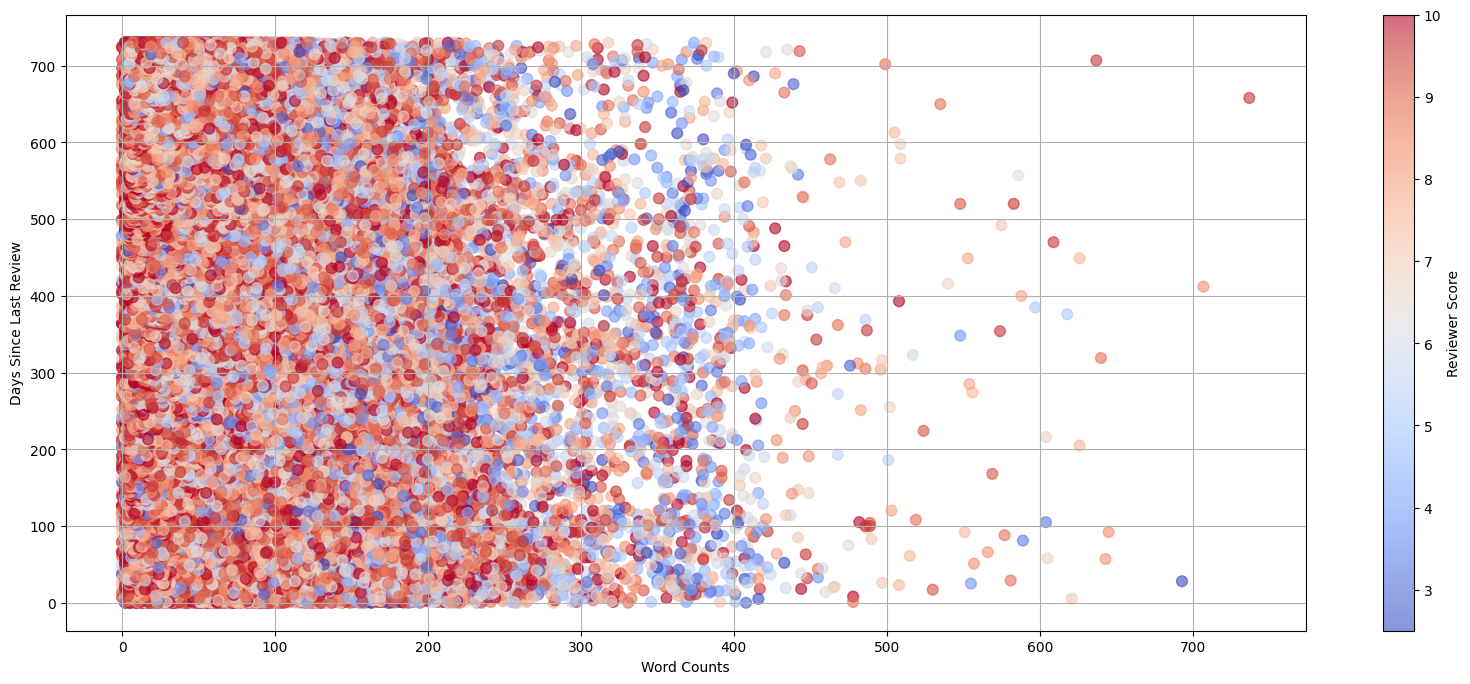

In [28]:
# Heatmap (scatter colorato) correlazioni numeriche (score, word counts, days since review)

# lunghezza recensione
dfhotel_reviews['review_length'] = (dfhotel_reviews['Review_Total_Positive_Word_Counts'] + dfhotel_reviews['Review_Total_Negative_Word_Counts'])

plt.figure(figsize=(20,8))
heatmap = plt.scatter(
    x=dfhotel_reviews['review_length'],
    y=dfhotel_reviews['days_since_review'],
    c=dfhotel_reviews["Reviewer_Score"],
    cmap="coolwarm",
    alpha=0.6,
    s=60,
    label='Reviewer Score'
)
plt.colorbar(heatmap, label='Reviewer Score')
plt.xlabel('Word Counts')
plt.ylabel('Days Since Last Review')
plt.grid(True)

plt.show()